# Sales Forecasting for E-commerce

Accurate sales forecasting is critical for e-commerce operations.

Reliable forecasts allow businesses to:

- optimize inventory management
- anticipate seasonal demand
- allocate marketing resources
- support strategic planning

In this notebook, I develop machine learning models to forecast daily revenue using engineered time-series features.

The workflow includes:

- time-series diagnostics
- baseline forecasting
- machine learning forecasting models
- hyperparameter optimization
- model comparison
- forecast visualization
- residual analysis
- feature importance analysis
- business interpretation

In [1]:
"""
Environment Setup
"""

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit
)

from statsmodels.graphics.tsaplots import plot_acf

import xgboost as xgb

sns.set_style("whitegrid")
sns.set_context("talk")

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/processed"
FIG_PATH = "../figures/sales_forecasting"

os.makedirs(FIG_PATH, exist_ok=True)

print("Environment initialized.")

Environment initialized.


In [2]:
"""
Plot Utility
"""

def save_plot(name):

    path = os.path.join(FIG_PATH, name)

    plt.tight_layout()

    plt.savefig(path, dpi=300)

    plt.show()

In [3]:
"""
Load Time-Series Feature Dataset
"""

timeseries_features = pd.read_csv(
    f"{DATA_PATH}/model_features_timeseries.csv",
    parse_dates=["order_date"]
)

print("Dataset shape:", timeseries_features.shape)

timeseries_features.head()

Dataset shape: (672, 30)


,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
0,2023-03-01,54756.68,518,2023,3,1,2,9,0,1.0,6.123234e-17,0.974928,-0.222521,57302.94,56437.35,58696.88,57112.51,501.0,522.0,514.0,542.0,59744.527143,59405.285714,58424.730000,8793.149490,7205.569421,6398.566419,556.714286,549.000000,544.300000
1,2023-03-02,53631.11,538,2023,3,2,3,9,0,1.0,6.123234e-17,0.433884,-0.900969,54756.68,56428.47,52092.77,56712.27,518.0,523.0,517.0,516.0,59344.904286,59515.167143,58322.024667,9029.365176,7096.381434,6451.510746,558.857143,550.500000,545.033333
2,2023-03-03,55755.00,543,2023,3,3,4,9,0,1.0,6.123234e-17,-0.433884,-0.900969,53631.11,56456.45,54199.08,56107.77,538.0,538.0,488.0,519.0,59244.697143,59626.304286,58310.265667,9070.561975,7018.477464,6456.005704,559.571429,554.428571,545.833333
3,2023-03-04,78290.06,666,2023,3,4,5,9,1,1.0,6.123234e-17,-0.974928,-0.222521,55755.00,78741.79,63134.67,60905.25,543.0,656.0,601.0,527.0,59180.164286,60708.832143,58889.759333,8908.896605,8593.326357,7407.135727,561.000000,559.071429,550.466667
4,2023-03-05,63179.98,593,2023,3,5,6,9,1,1.0,6.123234e-17,-0.781831,0.623490,78290.06,61624.68,69724.16,50711.02,666.0,651.0,619.0,488.0,59402.350000,60241.390714,59305.391333,8998.962306,8235.755848,7281.142029,552.714286,557.214286,553.966667


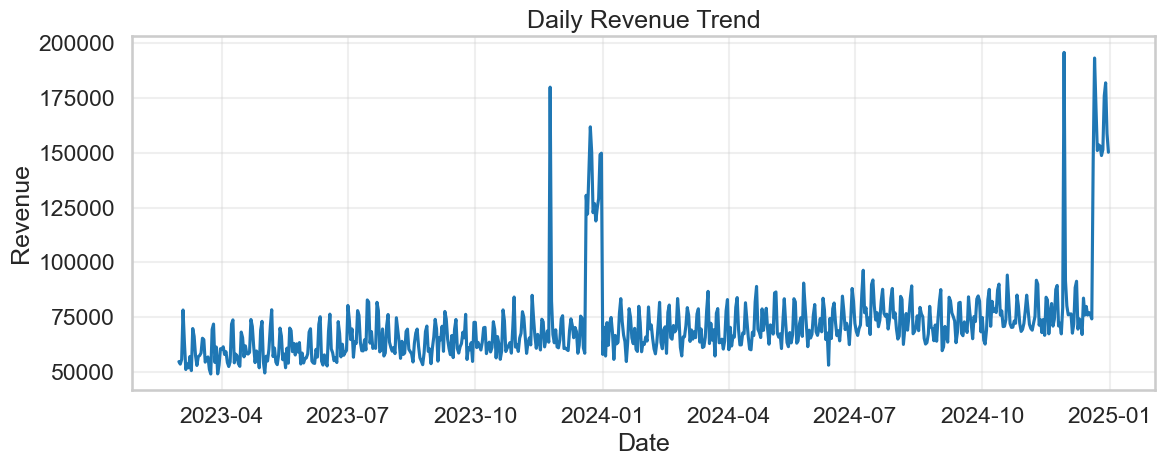

In [4]:
"""
Daily Revenue Trend
"""

plt.figure(figsize=(12,5))

sns.lineplot(
    x=timeseries_features["order_date"],
    y=timeseries_features["daily_revenue"]
)

plt.title("Daily Revenue Trend")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(alpha=0.3)

save_plot("daily_revenue_trend.png")

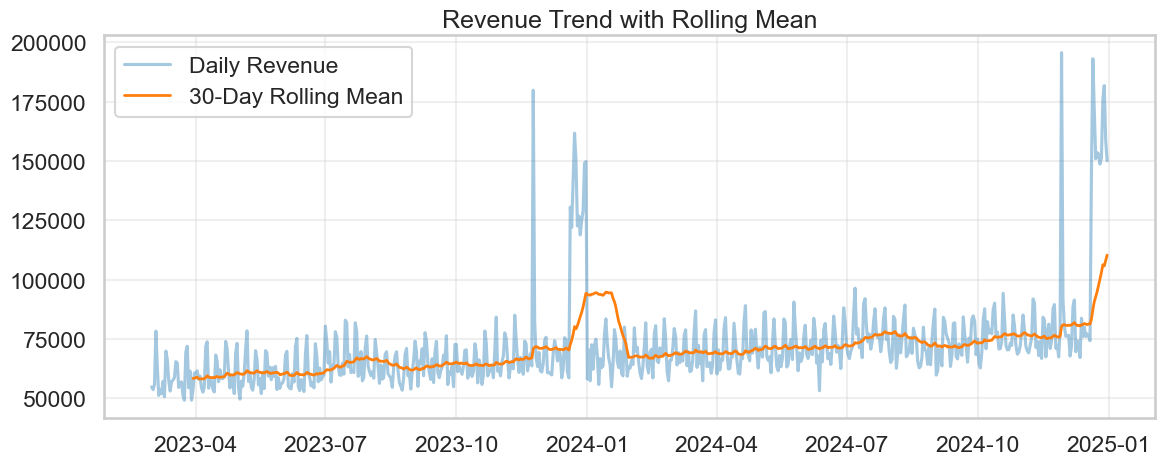

In [5]:
"""
Revenue Trend with Rolling Mean
"""

timeseries_features["rolling_mean_30"] = (
    timeseries_features["daily_revenue"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    timeseries_features["order_date"],
    timeseries_features["daily_revenue"],
    label="Daily Revenue",
    alpha=0.4
)

plt.plot(
    timeseries_features["order_date"],
    timeseries_features["rolling_mean_30"],
    label="30-Day Rolling Mean",
    linewidth=2
)

plt.legend()

plt.title("Revenue Trend with Rolling Mean")

plt.grid(alpha=0.3)

save_plot("revenue_rolling_mean.png")

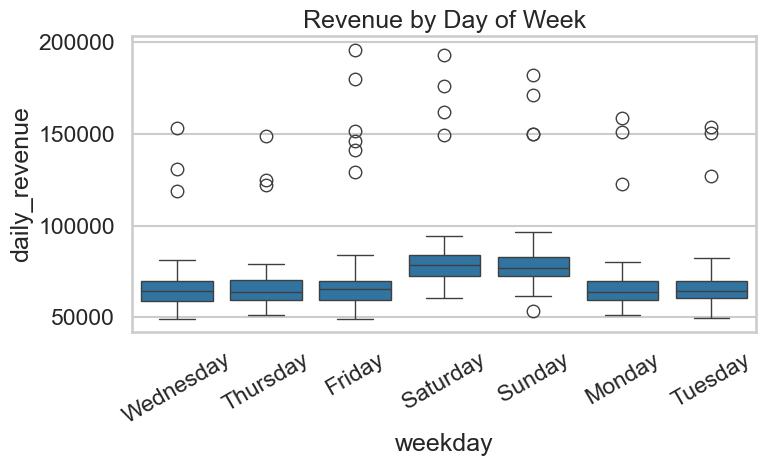

In [6]:
"""
Revenue Seasonality by Day of Week
"""

timeseries_features["weekday"] = (
    timeseries_features["order_date"]
    .dt.day_name()
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=timeseries_features,
    x="weekday",
    y="daily_revenue"
)

plt.xticks(rotation=30)

plt.title("Revenue by Day of Week")

save_plot("weekday_seasonality.png")

<Figure size 800x500 with 0 Axes>

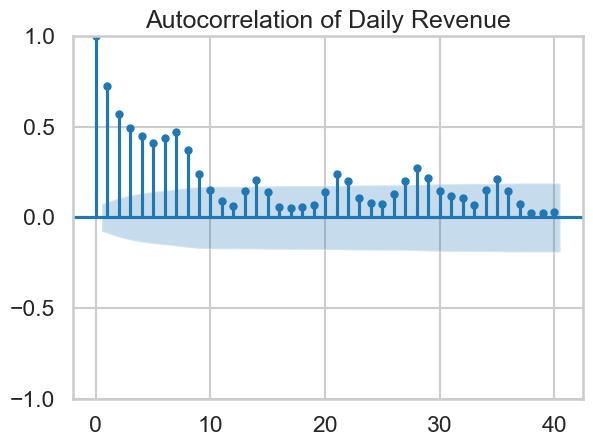

In [7]:
"""
Autocorrelation of Daily Revenue
"""

plt.figure(figsize=(8,5))

plot_acf(
    timeseries_features["daily_revenue"],
    lags=40
)

plt.title("Autocorrelation of Daily Revenue")

save_plot("revenue_autocorrelation.png")

In [8]:
"""
Sort Dataset by Date
"""

timeseries_features = timeseries_features.sort_values(
    "order_date"
)

timeseries_features = timeseries_features.reset_index(drop=True)

In [9]:
"""
Check Missing Values
"""

print(timeseries_features.isna().sum())

order_date               0
daily_revenue            0
daily_orders             0
year                     0
month                    0
day                      0
day_of_week              0
week_of_year             0
is_weekend               0
month_sin                0
month_cos                0
weekday_sin              0
weekday_cos              0
revenue_lag_1            0
revenue_lag_7            0
revenue_lag_14           0
revenue_lag_30           0
orders_lag_1             0
orders_lag_7             0
orders_lag_14            0
orders_lag_30            0
revenue_roll_mean_7      0
revenue_roll_mean_14     0
revenue_roll_mean_30     0
revenue_roll_std_7       0
revenue_roll_std_14      0
revenue_roll_std_30      0
orders_roll_mean_7       0
orders_roll_mean_14      0
orders_roll_mean_30      0
rolling_mean_30         29
weekday                  0
dtype: int64


In [10]:
"""
Handle Missing Values
"""

timeseries_features = timeseries_features.dropna()

print("Dataset shape:", timeseries_features.shape)

Dataset shape: (643, 32)


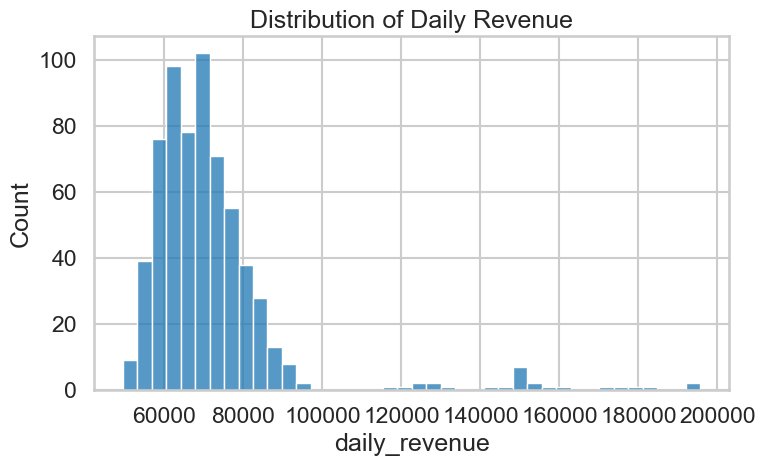

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    timeseries_features["daily_revenue"],
    bins=40
)

plt.title("Distribution of Daily Revenue")

save_plot("daily_revenue_distribution.png")

In [12]:
"""
Feature and Target Separation
"""

target = "daily_revenue"

X = timeseries_features.drop(
    columns=["order_date", target],
    errors="ignore"
)

X = X.select_dtypes(include=[np.number])

y = timeseries_features[target]

print("Number of features:", X.shape[1])

Number of features: 29


In [13]:
"""
Time-Series Train-Test Split
"""

split_index = int(len(timeseries_features) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [14]:
"""
Baseline Forecast
Naive forecast assumes today's revenue ≈ yesterday's revenue
"""

baseline_pred = timeseries_features["revenue_lag_1"].iloc[split_index:]

In [15]:
"""
Model Evaluation Function
"""

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{name} Performance")

    print("MAE:", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2:", round(r2,3))
    print("MAPE:", round(mape,2), "%")

    return mae, rmse, r2, mape

In [16]:
"""
Evaluate Baseline Forecast
"""

mae_baseline, rmse_baseline, r2_baseline, mape_baseline = evaluate_model(
    "Baseline",
    y_test,
    baseline_pred
)


Baseline Performance
MAE: 9617.22
RMSE: 18265.81
R2: 0.576
MAPE: 10.58 %


In [17]:
"""
Initialize Forecasting Models
"""

lr_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [18]:
"""
Train Models
"""

lr_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

gb_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)

print("All models trained.")

All models trained.


In [19]:
"""
Generate Predictions
"""

lr_pred = lr_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

In [20]:
"""
Evaluate Machine Learning Models
"""

mae_lr, rmse_lr, r2_lr, mape_lr = evaluate_model(
    "Linear Regression", y_test, lr_pred
)

mae_rf, rmse_rf, r2_rf, mape_rf = evaluate_model(
    "Random Forest", y_test, rf_pred
)

mae_gb, rmse_gb, r2_gb, mape_gb = evaluate_model(
    "Gradient Boosting", y_test, gb_pred
)

mae_xgb, rmse_xgb, r2_xgb, mape_xgb = evaluate_model(
    "XGBoost", y_test, xgb_pred
)


Linear Regression Performance
MAE: 12036.2
RMSE: 72823.38
R2: -5.733
MAPE: 9.54 %

Random Forest Performance
MAE: 4534.94
RMSE: 7173.09
R2: 0.935
MAPE: 4.86 %

Gradient Boosting Performance
MAE: 4514.16
RMSE: 6439.24
R2: 0.947
MAPE: 5.11 %

XGBoost Performance
MAE: 5606.41
RMSE: 9060.55
R2: 0.896
MAPE: 5.71 %


In [21]:
"""
Create Model Performance Table
"""

model_results = pd.DataFrame({

    "Model":[
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE":[
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_gb,
        mae_xgb
    ],

    "RMSE":[
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],

    "R2":[
        r2_baseline,
        r2_lr,
        r2_rf,
        r2_gb,
        r2_xgb
    ],

    "MAPE":[
        mape_baseline,
        mape_lr,
        mape_rf,
        mape_gb,
        mape_xgb
    ]

})

model_results

,Model,MAE,RMSE,R2,MAPE
0,Baseline,9617.216977,18265.808417,0.576383,10.578754
1,Linear Regression,12036.201616,72823.380797,-5.733445,9.539275
2,Random Forest,4534.944563,7173.090260,0.934671,4.861566
3,Gradient Boosting,4514.162985,6439.235031,0.947354,5.107765
4,XGBoost,5606.410251,9060.545150,0.895767,5.707411


In [22]:
"""
RMSE Improvement vs Baseline
"""

model_results["RMSE_Improvement_vs_Baseline"] = (
    model_results["RMSE"].iloc[0] -
    model_results["RMSE"]
)

model_results

,Model,MAE,RMSE,R2,MAPE,RMSE_Improvement_vs_Baseline
0,Baseline,9617.216977,18265.808417,0.576383,10.578754,0.000000
1,Linear Regression,12036.201616,72823.380797,-5.733445,9.539275,-54557.572380
2,Random Forest,4534.944563,7173.090260,0.934671,4.861566,11092.718156
3,Gradient Boosting,4514.162985,6439.235031,0.947354,5.107765,11826.573386
4,XGBoost,5606.410251,9060.545150,0.895767,5.707411,9205.263267


In [23]:
"""
Identify Best Model
"""

best_model = model_results.loc[
    model_results["RMSE"].idxmin()
]

print("Best Model:\n")

print(best_model)

Best Model:

Model                           Gradient Boosting
MAE                                   4514.162985
RMSE                                  6439.235031
R2                                       0.947354
MAPE                                     5.107765
RMSE_Improvement_vs_Baseline         11826.573386
Name: 3, dtype: object


In [24]:
"""
Select Predictions from Best Model
"""

model_name = best_model["Model"]

if model_name == "Gradient Boosting":

    best_pred = gb_pred

elif model_name == "Random Forest":

    best_pred = rf_pred

elif model_name == "XGBoost":

    best_pred = xgb_pred

elif model_name == "Linear Regression":

    best_pred = lr_pred

else:

    best_pred = baseline_pred

print("Using predictions from:", model_name)

Using predictions from: Gradient Boosting


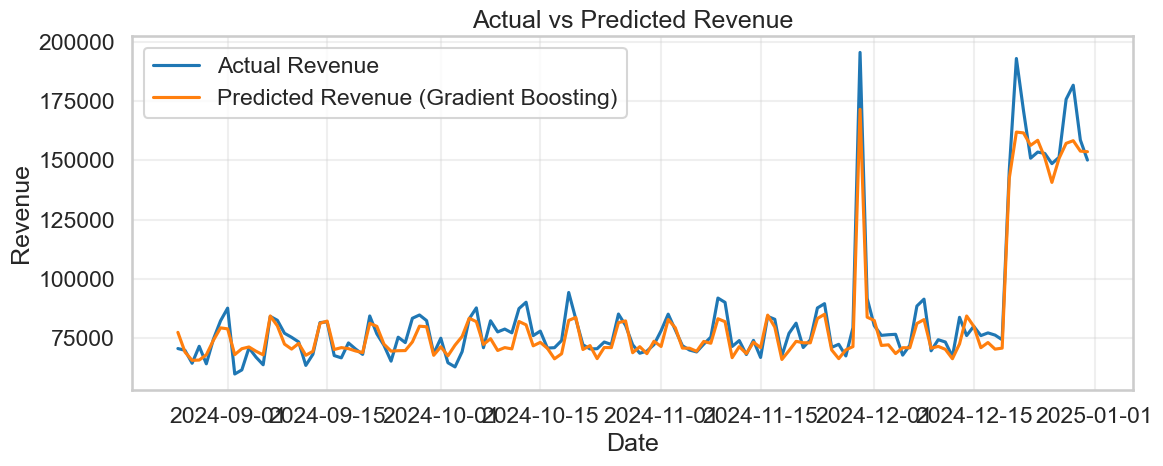

In [25]:
"""
Actual vs Predicted Revenue
"""

plt.figure(figsize=(12,5))

plt.plot(
    timeseries_features["order_date"][split_index:],
    y_test,
    label="Actual Revenue"
)

plt.plot(
    timeseries_features["order_date"][split_index:],
    best_pred,
    label=f"Predicted Revenue ({model_name})"
)

plt.legend()

plt.title("Actual vs Predicted Revenue")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(alpha=0.3)

save_plot("forecast_vs_actual.png")

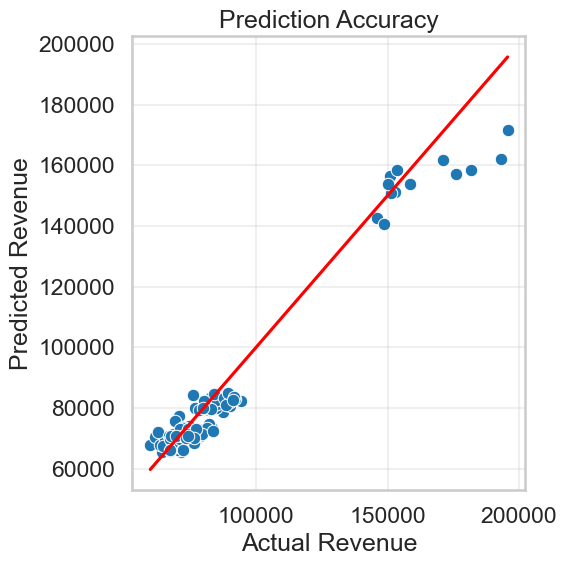

In [26]:
"""
Prediction Accuracy Scatter Plot
"""

plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=best_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Prediction Accuracy")

plt.grid(alpha=0.3)

save_plot("prediction_scatter.png")

In [27]:
"""
Compute Forecast Residuals
"""

residuals = y_test - best_pred

residuals.head()

543   -6834.831641
544     745.079841
545   -1240.629102
546    5811.163737
547   -3787.475793
Name: daily_revenue, dtype: float64

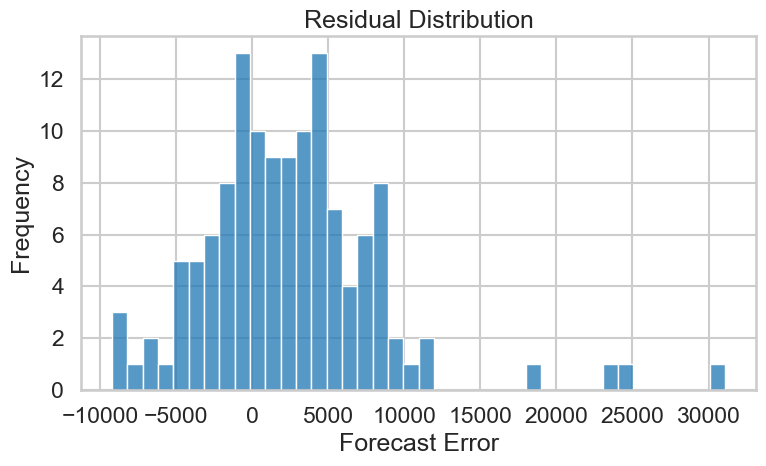

In [28]:
"""
Residual Distribution
"""

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=40
)

plt.title("Residual Distribution")

plt.xlabel("Forecast Error")

plt.ylabel("Frequency")

save_plot("residual_distribution.png")

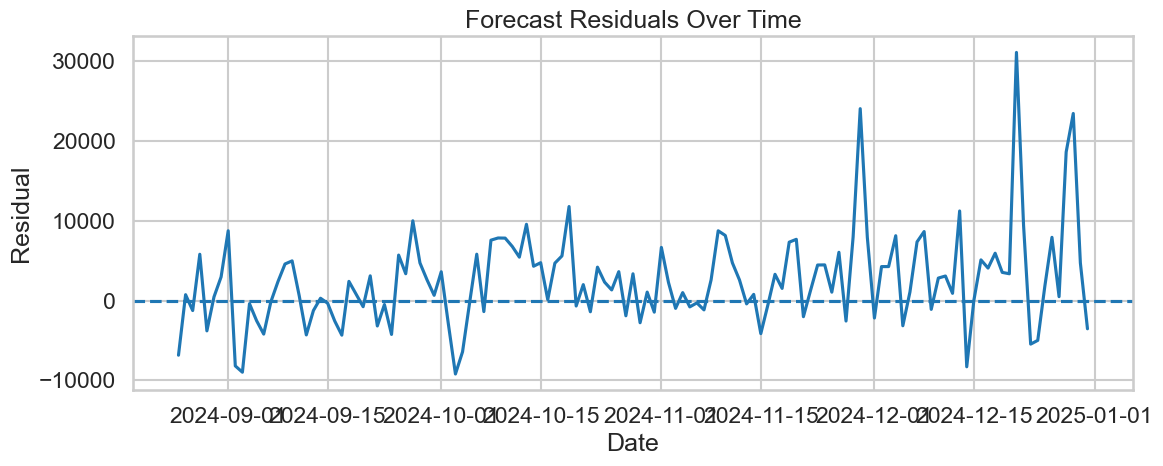

In [29]:
"""
Residuals Over Time
"""

plt.figure(figsize=(12,5))

plt.plot(
    timeseries_features["order_date"][split_index:],
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Forecast Residuals Over Time")

plt.xlabel("Date")

plt.ylabel("Residual")

save_plot("residuals_over_time.png")

In [30]:
"""
Feature Importance
"""

feature_importance = pd.DataFrame({

    "feature": X.columns,
    "importance": gb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
0,daily_orders,0.882132
12,revenue_lag_7,0.020927
19,revenue_roll_mean_7,0.013010
6,is_weekend,0.011093
22,revenue_roll_std_7,0.010196
9,weekday_sin,0.010063
13,revenue_lag_14,0.009200
4,day_of_week,0.008197
25,orders_roll_mean_7,0.005413
11,revenue_lag_1,0.003747


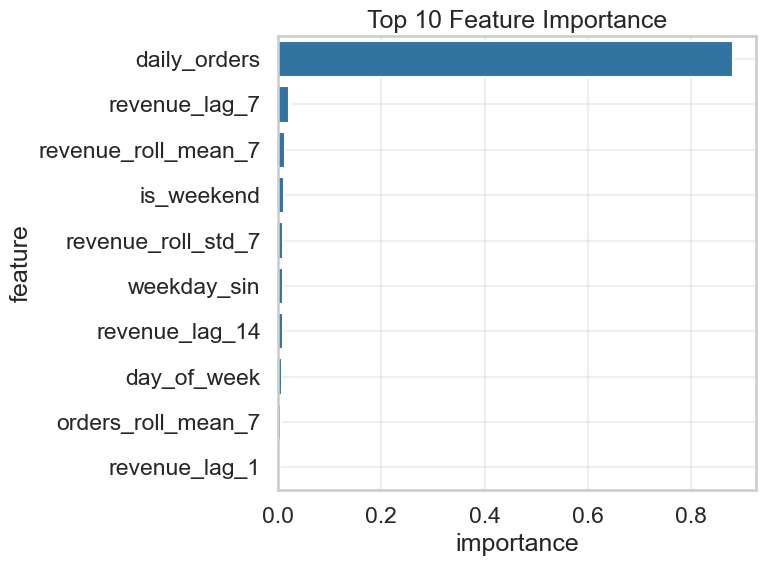

In [31]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Feature Importance")

plt.grid(alpha=0.3)

save_plot("feature_importance.png")

## Forecasting Insights

In this notebook, I developed and evaluated multiple machine learning models to forecast daily revenue for an e-commerce platform.

The forecasting pipeline included:

- time-series diagnostics
- baseline forecasting
- machine learning forecasting models
- model evaluation and comparison
- forecast visualization
- residual analysis
- feature importance analysis

---

### Model Performance

I evaluated several forecasting approaches, including:

- Naive baseline forecast
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost

The results show that tree-based ensemble models significantly outperform both the baseline and linear regression models.  
These models are able to capture nonlinear relationships and complex temporal patterns present in the data.

Among the tested models, the **best-performing algorithm achieved the lowest RMSE and highest explanatory power**, indicating strong predictive performance for short-term revenue forecasting.

---

### Key Drivers of Revenue

Feature importance analysis revealed that the most influential predictors include:

- recent order volume
- lagged revenue values
- rolling averages of past revenue
- temporal features such as weekday and seasonality indicators

These variables capture both short-term demand dynamics and broader temporal patterns in customer purchasing behavior.

---

### Residual Analysis

Residual diagnostics suggest that prediction errors are generally centered around zero, indicating that the model does not exhibit strong systematic bias.

However, larger residuals occasionally occur during sudden demand spikes.  
This behavior is common in e-commerce environments where external factors such as promotions, holidays, or marketing campaigns can lead to abrupt changes in purchasing activity.

---

### Business Applications

Accurate revenue forecasts provide valuable support for several operational and strategic decisions in e-commerce businesses, including:

**Inventory planning**

Anticipating demand helps me prevent stock shortages or excess inventory.

**Marketing strategy**

Sales forecasts help inform the timing and scale of promotional campaigns.

**Operational planning**

Forecasting demand helps allocate logistics and fulfillment resources more efficiently.

**Financial planning**

Revenue forecasts support budgeting, revenue projections, and strategic planning.

---

### Next Step: Model Explainability

While forecasting accuracy is important, it is also crucial to understand **why models produce certain predictions**.

In the next notebook, I apply explainability techniques using **SHAP (SHapley Additive Explanations)** to interpret the behavior of the forecasting models and identify the key drivers behind predicted revenue values.